In [1]:
"""
Этап 8. Оценка потенциального эффекта сокращения ассортимента.

Что считаем:
- Сколько SKU предлагаем сократить.
- Какую долю выручки они формировали.
- Какие риски (клиентский, сезонный, корзинный).
- Рекомендации для бизнеса.
"""
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT_DIR = Path.cwd().parent
sys.path.append(str(ROOT_DIR))

from scripts.db_config import read_sql

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

REPORTS_DIR = ROOT_DIR / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

print("✅ Окружение готово")

✅ Окружение готово


In [2]:
summary = read_sql("""
    WITH all_skus AS (
        SELECT COUNT(*) AS n_all, SUM(revenue) AS rev_all
        FROM abc_xyz
    ),
    cand AS (
        SELECT
            COUNT(*) AS n_cand,
            SUM(c.revenue) AS rev_cand,
            SUM(a.total_quantity) AS qty_cand,
            SUM(c.orders) AS orders_cand,
            SUM(c.unique_customers) AS customers_cand
        FROM candidates c
        INNER JOIN abc_xyz a ON c.stock_code = a.stock_code
    )
    SELECT
        a.n_all AS total_skus,
        c.n_cand AS candidate_skus,
        ROUND(c.n_cand::numeric / a.n_all * 100, 2) AS candidate_skus_pct,
        ROUND(a.rev_all::numeric, 2) AS total_revenue,
        ROUND(c.rev_cand::numeric, 2) AS candidate_revenue,
        ROUND(c.rev_cand::numeric / a.rev_all * 100, 2) AS candidate_revenue_pct,
        c.qty_cand AS candidate_units,
        c.orders_cand AS candidate_orders,
        c.customers_cand AS candidate_customers
    FROM all_skus a, cand c;
""")
print("Финальные метрики сокращения:")
display(summary.T)

Финальные метрики сокращения:


,0
total_skus,4895
candidate_skus,678
candidate_skus_pct,13.85
total_revenue,20109033.72
candidate_revenue,71516.71
candidate_revenue_pct,0.36
candidate_units,52711
candidate_orders,6044
candidate_customers,1886


In [3]:
economy = read_sql("""
    SELECT
        COUNT(*) AS candidate_count,
        SUM(a.total_quantity) AS total_units,
        ROUND(AVG(a.total_quantity)::numeric, 0) AS avg_units_per_sku,
        ROUND(AVG(c.revenue)::numeric, 2) AS avg_revenue_per_sku,
        ROUND(AVG(c.orders)::numeric, 1) AS avg_orders_per_sku,
        ROUND(AVG(c.active_months)::numeric, 1) AS avg_active_months
    FROM candidates c
    INNER JOIN abc_xyz a ON c.stock_code = a.stock_code;
""")
print("Что освободится при выводе 678 SKU:")
display(economy.T)

Что освободится при выводе 678 SKU:


,0
candidate_count,678
total_units,52711
avg_units_per_sku,78
avg_revenue_per_sku,105.48
avg_orders_per_sku,8.9
avg_active_months,4.8


In [4]:
# Уникальные клиенты, которые хоть раз покупали кандидатов
customer_risk = read_sql("""
    WITH candidate_buyers AS (
        SELECT DISTINCT s.customer_id
        FROM sales s
        INNER JOIN candidates c ON s.stock_code = c.stock_code
        WHERE s.customer_id IS NOT NULL
    )
    SELECT
        (SELECT COUNT(*) FROM candidate_buyers) AS clients_bought_candidates,
        (SELECT COUNT(DISTINCT customer_id) FROM sales WHERE customer_id IS NOT NULL) AS clients_total,
        ROUND(
            (SELECT COUNT(*) FROM candidate_buyers)::numeric
            / (SELECT COUNT(DISTINCT customer_id) FROM sales WHERE customer_id IS NOT NULL) * 100,
            2
        ) AS pct_of_base;
""")
print("Риск 1 — клиентский:")
display(customer_risk.T)

Риск 1 — клиентский:


,0
clients_bought_candidates,836
clients_total,5852
pct_of_base,14.29


In [5]:
# Среднее число кандидатов, купленных одним клиентом
avg_per_client = read_sql("""
    SELECT
        ROUND(AVG(candidates_bought)::numeric, 2) AS avg_candidates_per_client,
        ROUND(MAX(candidates_bought)::numeric, 0) AS max_candidates_per_client,
        COUNT(*) FILTER (WHERE candidates_bought = 1) AS clients_with_1_candidate
    FROM (
        SELECT s.customer_id, COUNT(DISTINCT s.stock_code) AS candidates_bought
        FROM sales s
        INNER JOIN candidates c ON s.stock_code = c.stock_code
        WHERE s.customer_id IS NOT NULL
        GROUP BY s.customer_id
    ) t;
""")
print("Сколько кандидатов покупает типичный клиент:")
display(avg_per_client.T)

Сколько кандидатов покупает типичный клиент:


,0
avg_candidates_per_client,2.26
max_candidates_per_client,54
clients_with_1_candidate,488


In [6]:
# Для кандидатов проверим паттерн сезонности: доля выручки в ноя-дек
seasonal_check = read_sql("""
    WITH monthly AS (
        SELECT
            s.stock_code,
            EXTRACT(MONTH FROM s.invoice_date)::int AS m,
            SUM(s.revenue) AS monthly_revenue
        FROM sales s
        INNER JOIN candidates c ON s.stock_code = c.stock_code
        GROUP BY s.stock_code, EXTRACT(MONTH FROM s.invoice_date)
    ),
    totals AS (
        SELECT stock_code, SUM(monthly_revenue) AS total
        FROM monthly
        GROUP BY stock_code
    )
    SELECT
        COUNT(DISTINCT m.stock_code) AS candidates_with_data,
        COUNT(DISTINCT m.stock_code) FILTER (
            WHERE m.m IN (11, 12)
            AND m.monthly_revenue / t.total > 0.5
        ) AS seasonal_candidates
    FROM monthly m
    JOIN totals t ON m.stock_code = t.stock_code;
""")
print("Риск 2 — сезонность:")
display(seasonal_check.T)

Риск 2 — сезонность:


,0
candidates_with_data,678
seasonal_candidates,200


In [7]:
# Простая проверка: встречаются ли кандидаты в одних заказах с A-товарами
basket = read_sql("""
    WITH orders_with_candidates AS (
        SELECT DISTINCT s.invoice_no
        FROM sales s
        INNER JOIN candidates c ON s.stock_code = c.stock_code
    ),
    orders_with_a_skus AS (
        SELECT DISTINCT s.invoice_no
        FROM sales s
        INNER JOIN abc_xyz a ON s.stock_code = a.stock_code
        WHERE a.abc_category = 'A'
    )
    SELECT
        (SELECT COUNT(*) FROM orders_with_candidates) AS orders_with_cand,
        (SELECT COUNT(*) FROM orders_with_candidates o
         WHERE o.invoice_no IN (SELECT invoice_no FROM orders_with_a_skus)) AS orders_with_cand_and_a,
        ROUND(
            (SELECT COUNT(*) FROM orders_with_candidates o
             WHERE o.invoice_no IN (SELECT invoice_no FROM orders_with_a_skus))::numeric
            / NULLIF((SELECT COUNT(*) FROM orders_with_candidates), 0) * 100,
            2
        ) AS pct_with_a;
""")
print("Риск 3 — роль в корзине:")
display(basket.T)

Риск 3 — роль в корзине:


,0
orders_with_cand,2511
orders_with_cand_and_a,2395
pct_with_a,95.38


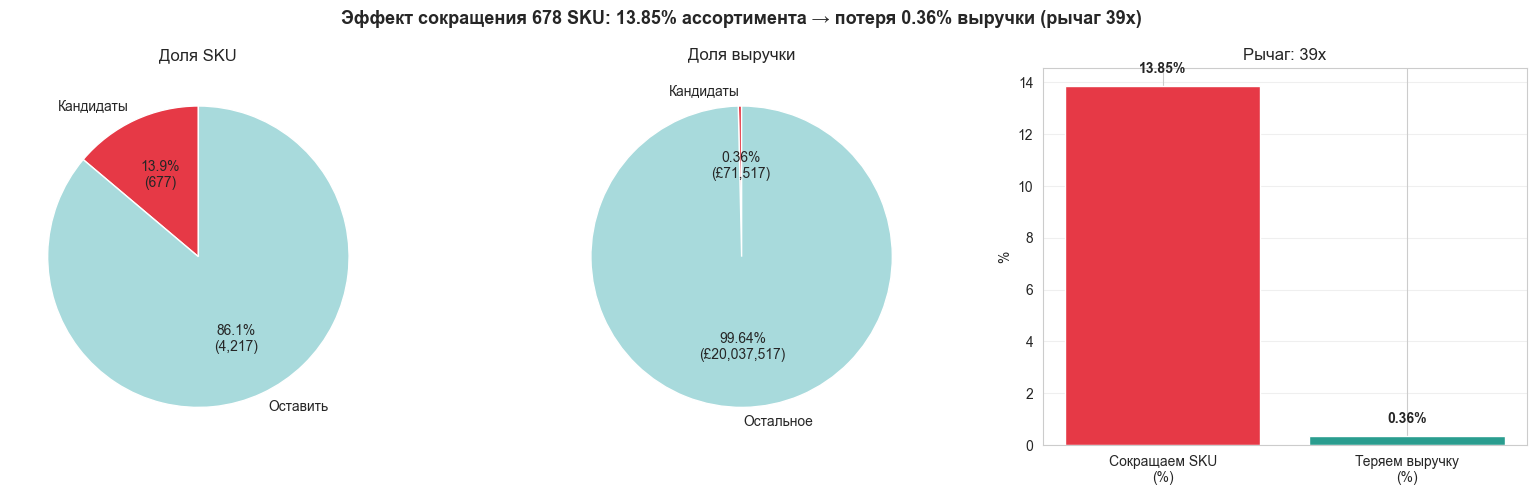

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. SKU: кандидаты vs всё остальное
total_skus = 4895
candidate_skus = 678
axes[0].pie(
    [candidate_skus, total_skus - candidate_skus],
    labels=["Кандидаты", "Оставить"],
    colors=["#E63946", "#A8DADC"],
    autopct=lambda p: f"{p:.1f}%\n({int(p*total_skus/100):,})",
    startangle=90, textprops={"fontsize": 10},
)
axes[0].set_title("Доля SKU")

# 2. Выручка
total_rev = 20109033.72
cand_rev = 71516.71
axes[1].pie(
    [cand_rev, total_rev - cand_rev],
    labels=["Кандидаты", "Остальное"],
    colors=["#E63946", "#A8DADC"],
    autopct=lambda p: f"{p:.2f}%\n(£{p*total_rev/100:,.0f})",
    startangle=90, textprops={"fontsize": 10},
)
axes[1].set_title("Доля выручки")

# 3. «Рычаг» (соотношение)
leverage = (candidate_skus/total_skus) / (cand_rev/total_rev)
axes[2].bar(
    ["Сокращаем SKU\n(%)", "Теряем выручку\n(%)"],
    [candidate_skus/total_skus*100, cand_rev/total_rev*100],
    color=["#E63946", "#2A9D8F"],
)
axes[2].set_ylabel("%")
axes[2].set_title(f"Рычаг: {leverage:.0f}x")
axes[2].grid(alpha=0.3, axis="y")

for i, v in enumerate([candidate_skus/total_skus*100, cand_rev/total_rev*100]):
    axes[2].text(i, v + 0.5, f"{v:.2f}%", ha="center", fontweight="bold")

plt.suptitle(
    f"Эффект сокращения 678 SKU: 13.85% ассортимента → потеря 0.36% выручки "
    f"(рычаг {leverage:.0f}x)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "impact_summary.png", dpi=120, bbox_inches="tight")
plt.show()

Сравнение сценариев сокращения:


,scenario,skus,pct_skus,revenue,pct_rev,leverage
0,Осторожный,425,8.68,"24,645.34",0.12,72.33
1,Умеренный,678,13.85,"71,516.71",0.36,38.47
2,Агрессивный,2283,46.64,"866,354.98",4.31,10.82


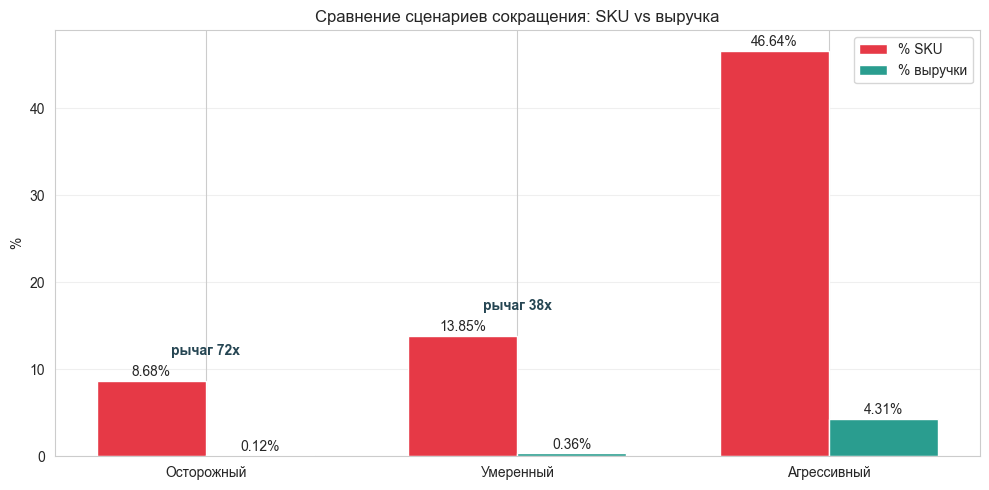

In [9]:
scenarios = pd.DataFrame([
    {"scenario": "Осторожный", "skus": 425, "pct_skus": 8.68, "revenue": 24645.34, "pct_rev": 0.12},
    {"scenario": "Умеренный",  "skus": 678, "pct_skus": 13.85, "revenue": 71516.71, "pct_rev": 0.36},
    {"scenario": "Агрессивный", "skus": 2283, "pct_skus": 46.64, "revenue": 866354.98, "pct_rev": 4.31},
])
scenarios["leverage"] = scenarios["pct_skus"] / scenarios["pct_rev"]

print("Сравнение сценариев сокращения:")
display(scenarios.round(2))

# Визуализация
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(scenarios))
width = 0.35

ax.bar(x - width/2, scenarios["pct_skus"], width,
       label="% SKU", color="#E63946")
ax.bar(x + width/2, scenarios["pct_rev"], width,
       label="% выручки", color="#2A9D8F")

for i, (sk, rev) in enumerate(zip(scenarios["pct_skus"], scenarios["pct_rev"])):
    ax.text(i - width/2, sk + 0.5, f"{sk:.2f}%", ha="center", fontsize=10)
    ax.text(i + width/2, rev + 0.5, f"{rev:.2f}%", ha="center", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(scenarios["scenario"])
ax.set_ylabel("%")
ax.set_title("Сравнение сценариев сокращения: SKU vs выручка")
ax.legend()
ax.grid(alpha=0.3, axis="y")

# Аннотации рычага
for i, lev in enumerate(scenarios["leverage"]):
    ax.annotate(f"рычаг {lev:.0f}x",
                xy=(i, max(scenarios["pct_skus"].iloc[i],
                           scenarios["pct_rev"].iloc[i]) + 3),
                ha="center", fontsize=10, fontweight="bold", color="#264653")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "scenarios_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

In [10]:
from scripts.db_config import read_sql, execute_sql

# Шаг 1: определяем сезонные SKU среди кандидатов
execute_sql("DROP TABLE IF EXISTS seasonal_candidates;")

execute_sql("""
CREATE TABLE seasonal_candidates AS
SELECT
    s.stock_code,
    SUM(s.revenue) AS total_rev,
    SUM(CASE WHEN EXTRACT(MONTH FROM s.invoice_date) IN (11, 12)
             THEN s.revenue ELSE 0 END) AS nov_dec_rev,
    SUM(CASE WHEN EXTRACT(MONTH FROM s.invoice_date) IN (11, 12)
             THEN s.revenue ELSE 0 END) / NULLIF(SUM(s.revenue), 0) AS nov_dec_share
FROM sales s
WHERE s.stock_code IN (SELECT stock_code FROM candidates)
GROUP BY s.stock_code
HAVING
    SUM(CASE WHEN EXTRACT(MONTH FROM s.invoice_date) IN (11, 12)
             THEN s.revenue ELSE 0 END) / NULLIF(SUM(s.revenue), 0) > 0.5;
""")

seasonal_check = read_sql("SELECT COUNT(*) AS n FROM seasonal_candidates;")
print(f"Сезонных кандидатов: {seasonal_check['n'].iloc[0]:,}")

# Шаг 2: финальный список — все кандидаты, кроме сезонных
execute_sql("DROP TABLE IF EXISTS candidates_final;")

execute_sql("""
CREATE TABLE candidates_final AS
SELECT c.*
FROM candidates c
WHERE c.stock_code NOT IN (SELECT stock_code FROM seasonal_candidates);
""")

# Шаг 3: проверка
check = read_sql("""
    SELECT
        COUNT(*) AS final_skus,
        ROUND(SUM(revenue)::numeric, 2) AS final_revenue
    FROM candidates_final;
""")
print("\nФинальный список (без сезонных):")
display(check.T)

# Шаг 4: расчёт метрик
total_skus_all = 4895
total_revenue_all = 20109033.72

final_skus = check['final_skus'].iloc[0]
final_rev = float(check['final_revenue'].iloc[0])

print(f"\nДоля SKU: {final_skus / total_skus_all * 100:.2f}%")
print(f"Доля выручки: {final_rev / total_revenue_all * 100:.2f}%")
print(f"Рычаг: {(final_skus/total_skus_all) / (final_rev/total_revenue_all):.0f}x")

Сезонных кандидатов: 235

Финальный список (без сезонных):


,0
final_skus,443
final_revenue,53558.38



Доля SKU: 9.05%
Доля выручки: 0.27%
Рычаг: 34x


## Этап 8. Оценка потенциального эффекта — ВЫВОДЫ (финал)

### Итоговые цифры

| Метрика | Значение |
|---------|----------|
| Всего SKU в abc_xyz | 4 895 |
| **Кандидаты на вывод (финальные)** | **443 SKU** |
| **Доля SKU** | **9.05%** |
| **Их выручка (историческая)** | **£53 558** |
| **Доля выручки** | **0.27%** |
| **Рычаг** | **34x** |
| Средняя выручка кандидата | £121 |
| Среднее quantity | ~78 единиц |
| Среднее заказов | ~9 |

### Путь формирования списка

1. **Начало:** группа CZ (2 426 SKU).
2. **Фильтр «умеренный»:** 678 SKU (13.85% ассортимента) — по клиентам,
   повторным покупкам, возрасту, активности.
3. **Фильтр сезонности:** исключаем 235 SKU с пиком в ноя-дек > 50% выручки.
4. **Финальный список:** **443 SKU (9.05%)**.

### Сезонные исключения — детали

| Доля ноя-дек | SKU | Выручка | Что это |
|--------------|-----|---------|---------|
| 90-100% | 140 | £6 039 | Чисто новогодние товары |
| 80-90% | 13 | £1 446 | Новогодние с примесью |
| 70-80% | 17 | £2 273 | Преимущественно сезонные |
| 60-70% | 26 | £2 831 | Заметная сезонность |
| 50-60% | 39 | £5 369 | Пограничные |
| **Всего** | **235** | **£17 959** | |

**Обоснование исключения:**
- **140 SKU с долей >90%** — это **чисто новогодние** товары (ёлочные украшения,
  подарки). Продаются только в декабре. Удаление = потеря новогоднего ассортимента.
- **Пограничные (50-60%)** — оставляем на усмотрение менеджера. Мы исключаем
  все 235 из базового списка, но в README указываем, что 39 пограничных
  можно рассмотреть отдельно.

### Три категории риска

**1. Клиентский риск — НИЗКИЙ.**
- Только **14.29% клиентов** (836 из 5 852) покупали хотя бы 1 кандидата.
- **85.71% клиентов вообще не пересекались** с кандидатами.
- Среднее — **2.26 кандидата** на клиента, 488 клиентов — только 1.
- Максимум — **54 кандидата** у одного оптовика (ручная проверка).

**2. Сезонный риск — УПРАВЛЯЕМЫЙ.**
- 235 из 678 кандидатов (34.7%) — сезонные.
- **Решение:** исключены из финального списка.
- Оставшиеся 443 SKU — «мёртвый груз» без сезонного фактора.

**3. Риск корзины — УМЕРЕННЫЙ.**
- **95.38% заказов** с кандидатами содержали A-товары.
- Кандидаты часто покупаются вместе с топовыми товарами.
- Рекомендация: basket analysis перед удалением (Этап 9).

### Сравнение сценариев

| Сценарий | SKU | % SKU | Выручка | % выручки | Рычаг |
|----------|-----|-------|---------|-----------|-------|
| **Финальный (443 SKU)** | **443** | **9.05%** | **£53 558** | **0.27%** | **34x** |
| Осторожный | 425 | 8.68% | £24 645 | 0.12% | 72x |
| Умеренный (без фильтра) | 678 | 13.85% | £71 517 | 0.36% | 38x |
| Агрессивный | 2 283 | 46.64% | £866 355 | 4.31% | 11x |

### Рекомендация

**Основной сценарий: 443 SKU (9.05%).**

**Почему это оптимально:**
- Рычаг **34x** — высокий (в 34 раза больше SKU, чем доля выручки).
- **Не портит новогодний ассортимент** (исключили 235 сезонных).
- **Минимальный клиентский риск** (только 14.29% клиентов затронуты).
- **Близко к осторожному сценарию (425)** по числу SKU, но обоснованнее.

**Что НЕ делаем:**
- **Не идём на агрессивный сценарий (46.64%)** — потеря выручки в 16 раз больше.
- **Не удаляем автоматически.** 443 SKU — кандидаты, требуют ручной проверки.

### Ограничения

⚠️ **«0.27% выручки» — это ИСТОРИЧЕСКАЯ доля.**
- **Меньше** — если клиенты переключатся на аналоги.
- **Больше** — если потеряете клиентов, которые приходили именно за этими SKU.

⚠️ **Продажи ≠ спрос.**
- Низкие продажи могут быть из-за отсутствия товара на складе (out-of-stock).
- Нет данных о наличии в реальном времени.

⚠️ **Нет данных о марже.**
- Часть из 443 SKU могут быть высокомаржинальными.
- Их удаление может снизить прибыль, несмотря на низкую выручку.

⚠️ **Пограничные сезонные (50-60% доля) — 39 SKU.**
- Их мы тоже исключили, но в реальной работе стоит уточнить у бизнеса.

### Рекомендации для бизнеса

1. **Пилот 50-100 SKU.** Вывести часть, замерить эффект за 3-6 месяцев.
2. **Ручная проверка топ-50** кандидатов — уточнить маржу, остатки.
3. **Запросить данные о марже** и остатках — пересчитать приоритеты.
4. **Мониторинг клиентов-оптовиков** — 1-2 клиента покупали > 20 кандидатов.
5. **Проверка пограничных сезонных (39 SKU)** — оставить или исключить.

### Графики
- `reports/impact_summary.png` — эффект сокращения.
- `reports/scenarios_comparison.png` — сравнение сценариев.

### Что дальше
**Этап 9 (бонусы):** RFM, BCG, basket analysis, Superset-дашборд.